# Inibsa Dataset Exploratory Analysis

Objective: understand the provided `Datasets.xlsx` from multiple business dimensions and prepare reusable aggregates for a Smart Demand Signals solution.

Main questions:
- What is inside each sheet, and where are the data quality risks?
- How do sales evolve over time by product block, family, customer, and geography?
- How does observed purchase behavior compare with declared potential?
- What simple features can support commodity repurchase alerts and technical-product churn-risk alerts?

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

try:
    display
except NameError:
    def display(x):
        print(x.to_string() if hasattr(x, "to_string") else x)

CWD = Path.cwd().resolve()
DATA_PATH_CANDIDATES = [
    CWD / "Datasets.xlsx",
    CWD.parent / "Datasets.xlsx",
    CWD.parent.parent / "Datasets.xlsx",
    Path("/Users/huataipan/Wichai/Hackathons/Interbcn/Datasets.xlsx"),
]
DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, "Could not find Datasets.xlsx. Run the notebook from the project folder or update DATA_PATH."
print(f"Using data file: {DATA_PATH}")
print(f"Matplotlib available: {HAS_MPL}")

Using data file: /Users/huataipan/Wichai/Hackathons/Interbcn/Datasets.xlsx
Matplotlib available: True


## 1. Load Workbook and Inspect Sheet Inventory

In [2]:
def load_dataset_sheets(data_path):
    """Load workbook sheets. Fall back to CSV snapshots if the active kernel lacks openpyxl."""
    try:
        loaded = pd.read_excel(data_path, sheet_name=None)
        print(f"Loaded Excel workbook: {data_path}")
        return loaded
    except ImportError as exc:
        if "openpyxl" not in str(exc):
            raise
        csv_dir_candidates = [
            CWD / "notebook_data",
            CWD.parent / "notebook_data",
            Path("/Users/huataipan/Wichai/Hackathons/Interbcn/notebook_data"),
        ]
        csv_dir = next((p for p in csv_dir_candidates if p.exists()), None)
        if csv_dir is None:
            raise RuntimeError(
                "The active Python kernel is missing openpyxl and notebook_data/*.csv was not found. "
                "Install openpyxl or keep the notebook_data folder next to this notebook."
            ) from exc
        parse_dates = {
            "Ventas": ["Fecha"],
            "Campañas": ["Fecha inicio", "Fecha fin"],
        }
        loaded = {}
        for sheet_name in ["Potencial", "Clientes", "Productos", "Ventas", "Campañas"]:
            csv_path = csv_dir / f"{sheet_name}.csv"
            if not csv_path.exists():
                raise FileNotFoundError(f"Missing CSV fallback: {csv_path}")
            loaded[sheet_name] = pd.read_csv(csv_path, parse_dates=parse_dates.get(sheet_name, None))
        print(f"Loaded CSV fallback data from: {csv_dir}")
        return loaded

sheets = load_dataset_sheets(DATA_PATH)
print("Sheets:", list(sheets.keys()))

inventory = []
for name, df in sheets.items():
    inventory.append({
        "sheet": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicated_rows": int(df.duplicated().sum()),
    })
inventory_df = pd.DataFrame(inventory)
display(inventory_df)

Loaded CSV fallback data from: /Users/huataipan/Wichai/Hackathons/Interbcn/notebook_data
Sheets: ['Potencial', 'Clientes', 'Productos', 'Ventas', 'Campañas']


,sheet,rows,columns,missing_cells,duplicated_rows
0,Potencial,33093,4,0,0
1,Clientes,11031,3,0,30
2,Productos,25,4,0,0
3,Ventas,162546,6,0,0
4,Campañas,10,3,0,0


In [3]:
for name, df in sheets.items():
    print()
    print(f"--- {name} ---")
    display(df.head(5))


--- Potencial ---


,Id.Cliente,Familia,Categoria Productos,Potencial_H
0,3,Anestesia,Categoria C1,"2,223.12"
1,26,Anestesia,Categoria C1,"2,223.12"
2,30,Anestesia,Categoria C1,"2,223.12"
3,46,Anestesia,Categoria C1,"4,546.72"
4,64,Anestesia,Categoria C1,"2,223.12"



--- Clientes ---


,Id. Cliente,Unnamed: 1,Provincia
0,14052,1001,Álava
1,1000100724,1001,Álava
2,1000061782,1002,Álava
3,1000100667,1002,Álava
4,1000100675,1002,Álava



--- Productos ---


,Id.Prod,Bloque analítico,Categoria_H,Familia_H
0,4565,Commodities,Categoria C1,Familia C1
1,4566,Commodities,Categoria C1,Familia C1
2,3399,Commodities,Categoria C1,Familia C1
3,178,Commodities,Categoria C1,Familia C1
4,4567,Commodities,Categoria C1,Familia C1



--- Ventas ---


,Num.Fact,Fecha,Id. Cliente,Id. Producto,Unidades,Valores_H
0,3810000197,2024-01-03,1000078762,4566,-1,-141.93
1,3810000198,2024-01-12,1000077124,3408,-10,-634.15
2,3810000198,2024-01-12,1000077124,5099,-1,-329.32
3,3810000200,2024-02-23,27995,4911,-60,"-3,931.91"
4,3810000201,2024-03-22,35333,5099,-4,"-1,142.11"



--- Campañas ---


,Campaña,Fecha inicio,Fecha fin
0,2021_1,2021-11-24,2021-11-26
1,2022_1,2022-03-14,2022-03-26
2,2022_2,2022-11-24,2022-11-25
3,2023_1,2023-09-12,2023-09-15
4,2023_2,2023-11-24,2023-11-24


## 2. Schema, Missing Values, and Basic Data Quality

This section keeps the raw field names visible because they are useful when later designing joins and traceability rules.

In [4]:
def schema_report(df, sheet_name):
    report = pd.DataFrame({
        "sheet": sheet_name,
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "unique": df.nunique(dropna=True).values,
    })
    return report

schema = pd.concat([schema_report(df, name) for name, df in sheets.items()], ignore_index=True)
display(schema)

,sheet,column,dtype,non_null,missing,unique
0,Potencial,Id.Cliente,int64,33093,0,11031
1,Potencial,Familia,object,33093,0,3
2,Potencial,Categoria Productos,object,33093,0,3
3,Potencial,Potencial_H,float64,33093,0,188
4,Clientes,Id. Cliente,int64,11031,0,10994
5,Clientes,Unnamed: 1,int64,11031,0,2311
6,Clientes,Provincia,object,11031,0,53
7,Productos,Id.Prod,int64,25,0,25
8,Productos,Bloque analítico,object,25,0,2
9,Productos,Categoria_H,object,25,0,3


In [5]:
quality = []
for name, df in sheets.items():
    quality.append({
        "sheet": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "columns_with_missing": int((df.isna().sum() > 0).sum()),
        "total_missing": int(df.isna().sum().sum()),
    })
quality_df = pd.DataFrame(quality)
display(quality_df)

,sheet,rows,columns,duplicate_rows,columns_with_missing,total_missing
0,Potencial,33093,4,0,0,0
1,Clientes,11031,3,30,0,0
2,Productos,25,4,0,0,0
3,Ventas,162546,6,0,0,0
4,Campañas,10,3,0,0,0


## 3. Prepare Core Analytical Tables

In [6]:
ventas = sheets["Ventas"].copy()
clientes = sheets["Clientes"].copy()
productos = sheets["Productos"].copy()
potencial = sheets["Potencial"].copy()
campanias = sheets["Campañas"].copy()

ventas["Fecha"] = pd.to_datetime(ventas["Fecha"], errors="coerce")
ventas["Unidades"] = pd.to_numeric(ventas["Unidades"], errors="coerce")
ventas["Valores_H"] = pd.to_numeric(ventas["Valores_H"], errors="coerce")
ventas["Año"] = ventas["Fecha"].dt.year
ventas["Mes"] = ventas["Fecha"].dt.to_period("M").astype(str)
ventas["Trimestre"] = ventas["Fecha"].dt.to_period("Q").astype(str)
ventas["Es_devolucion_o_abono"] = ventas["Unidades"] < 0
ventas["Valor_cero"] = ventas["Valores_H"].fillna(0).eq(0)

ventas_prod = ventas.merge(
    productos,
    left_on="Id. Producto",
    right_on="Id.Prod",
    how="left",
    validate="many_to_one",
)

# The second column in Clientes is unnamed in the workbook; keep it but give it a useful label.
clientes = clientes.rename(columns={clientes.columns[1]: "Codigo_postal"})
duplicate_customer_ids = int(clientes["Id. Cliente"].duplicated().sum())
clientes_master = clientes.drop_duplicates(subset=["Id. Cliente"], keep="first").copy()

ventas_full = ventas_prod.merge(
    clientes_master,
    on="Id. Cliente",
    how="left",
    validate="many_to_one",
)

ventas_pos = ventas_full[(ventas_full["Unidades"] > 0) & (ventas_full["Valores_H"] > 0)].copy()
ventas_nonzero = ventas_full[ventas_full["Valores_H"] != 0].copy()

print("ventas_full shape:", ventas_full.shape)
print("positive sales rows:", len(ventas_pos))
print("duplicate customer IDs in Clientes:", duplicate_customer_ids)
print("unmatched products:", int(ventas_prod["Id.Prod"].isna().sum()))
print("unmatched customers:", int(ventas_full["Provincia"].isna().sum()))

ventas_full shape: (162546, 17)
positive sales rows: 156921
duplicate customer IDs in Clientes: 37
unmatched products: 0
unmatched customers: 623


## 4. Executive Overview KPIs

In [7]:
date_min = ventas_full["Fecha"].min()
date_max = ventas_full["Fecha"].max()

kpis = pd.DataFrame([
    {"metric": "date_start", "value": date_min},
    {"metric": "date_end", "value": date_max},
    {"metric": "sales_rows", "value": len(ventas_full)},
    {"metric": "positive_sales_rows", "value": len(ventas_pos)},
    {"metric": "unique_invoices", "value": ventas_full["Num.Fact"].nunique()},
    {"metric": "buying_customers", "value": ventas_full["Id. Cliente"].nunique()},
    {"metric": "all_customers_in_master", "value": clientes_master["Id. Cliente"].nunique()},
    {"metric": "products", "value": productos["Id.Prod"].nunique()},
    {"metric": "gross_units_positive", "value": ventas_pos["Unidades"].sum()},
    {"metric": "gross_value_positive", "value": ventas_pos["Valores_H"].sum()},
    {"metric": "net_units_all_rows", "value": ventas_full["Unidades"].sum()},
    {"metric": "net_value_all_rows", "value": ventas_full["Valores_H"].sum()},
])
display(kpis)

,metric,value
0,date_start,2021-01-04 00:00:00
1,date_end,2025-12-29 00:00:00
2,sales_rows,162546
3,positive_sales_rows,156921
4,unique_invoices,99299
5,buying_customers,8095
6,all_customers_in_master,10994
7,products,25
8,gross_units_positive,795007
9,gross_value_positive,"110,566,950.48"


In [8]:
anomaly_summary = pd.DataFrame({
    "condition": ["negative units", "zero value", "missing date", "unmatched product", "unmatched customer"],
    "rows": [
        int((ventas_full["Unidades"] < 0).sum()),
        int((ventas_full["Valores_H"].fillna(0) == 0).sum()),
        int(ventas_full["Fecha"].isna().sum()),
        int(ventas_full["Id.Prod"].isna().sum()),
        int(ventas_full["Provincia"].isna().sum()),
    ],
})
anomaly_summary["share_of_sales_rows"] = anomaly_summary["rows"] / len(ventas_full)
display(anomaly_summary)

,condition,rows,share_of_sales_rows
0,negative units,1951,0.01
1,zero value,1456,0.01
2,missing date,0,0.00
3,unmatched product,0,0.00
4,unmatched customer,623,0.00


## 5. Time Dimension

Use positive sales for demand-pattern analysis; keep net sales separately when finance reconciliation is needed.

In [9]:
yearly = ventas_pos.groupby("Año").agg(
    rows=("Num.Fact", "size"),
    invoices=("Num.Fact", "nunique"),
    clients=("Id. Cliente", "nunique"),
    units=("Unidades", "sum"),
    value=("Valores_H", "sum"),
).reset_index()
yearly["value_yoy"] = yearly["value"].pct_change()
yearly["clients_yoy"] = yearly["clients"].pct_change()
display(yearly)

,Año,rows,invoices,clients,units,value,value_yoy,clients_yoy
0,2021,30774,19370,5241,162470,"21,453,474.47",NaN,NaN
1,2022,30559,19099,5244,154758,"21,222,568.26",-0.01,0.00
2,2023,30305,18565,5191,150633,"21,280,349.00",0.00,-0.01
3,2024,32347,19781,5453,162012,"22,767,059.84",0.07,0.05
4,2025,32936,20349,5611,165134,"23,843,498.91",0.05,0.03


,Mes,Bloque analítico,value,units,clients,invoices
108,2025-07,Commodities,"825,375.60",10785,990,1086
109,2025-07,Productos Técnicos,"954,088.94",2604,502,597
110,2025-08,Commodities,"281,363.15",3725,360,375
111,2025-08,Productos Técnicos,"278,384.80",704,156,166
112,2025-09,Commodities,"978,301.79",12844,1165,1269
113,2025-09,Productos Técnicos,"1,341,872.31",3400,671,812
114,2025-10,Commodities,"946,126.96",12159,1101,1190
115,2025-10,Productos Técnicos,"1,539,334.82",3971,738,903
116,2025-11,Commodities,"911,717.53",12098,1049,1121
117,2025-11,Productos Técnicos,"1,263,867.90",3333,621,752


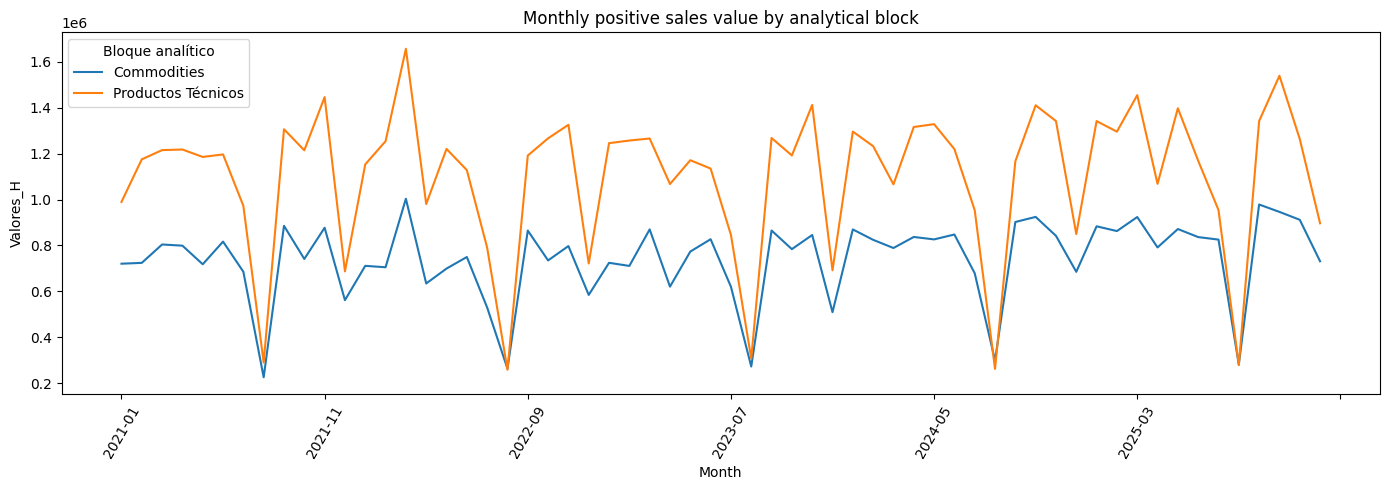

In [10]:
monthly = ventas_pos.groupby(["Mes", "Bloque analítico"]).agg(
    value=("Valores_H", "sum"),
    units=("Unidades", "sum"),
    clients=("Id. Cliente", "nunique"),
    invoices=("Num.Fact", "nunique"),
).reset_index()
monthly_pivot = monthly.pivot(index="Mes", columns="Bloque analítico", values="value").fillna(0)
display(monthly.tail(12))

if HAS_MPL:
    ax = monthly_pivot.plot(figsize=(14, 5), title="Monthly positive sales value by analytical block")
    ax.set_xlabel("Month")
    ax.set_ylabel("Valores_H")
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

,Trimestre,Familia_H,value,clients
64,2025Q1,Familia C1,"2,097,718.76",2255
65,2025Q1,Familia C2,"571,878.25",745
66,2025Q1,Familia T1,"3,061,814.03",1260
67,2025Q1,Familia T2,"1,030,274.41",614
68,2025Q2,Familia C1,"1,955,568.67",2149
69,2025Q2,Familia C2,"543,412.83",731
70,2025Q2,Familia T1,"2,709,794.97",1191
71,2025Q2,Familia T2,"925,213.65",572
72,2025Q3,Familia C1,"1,619,142.82",1889
73,2025Q3,Familia C2,"465,897.72",625


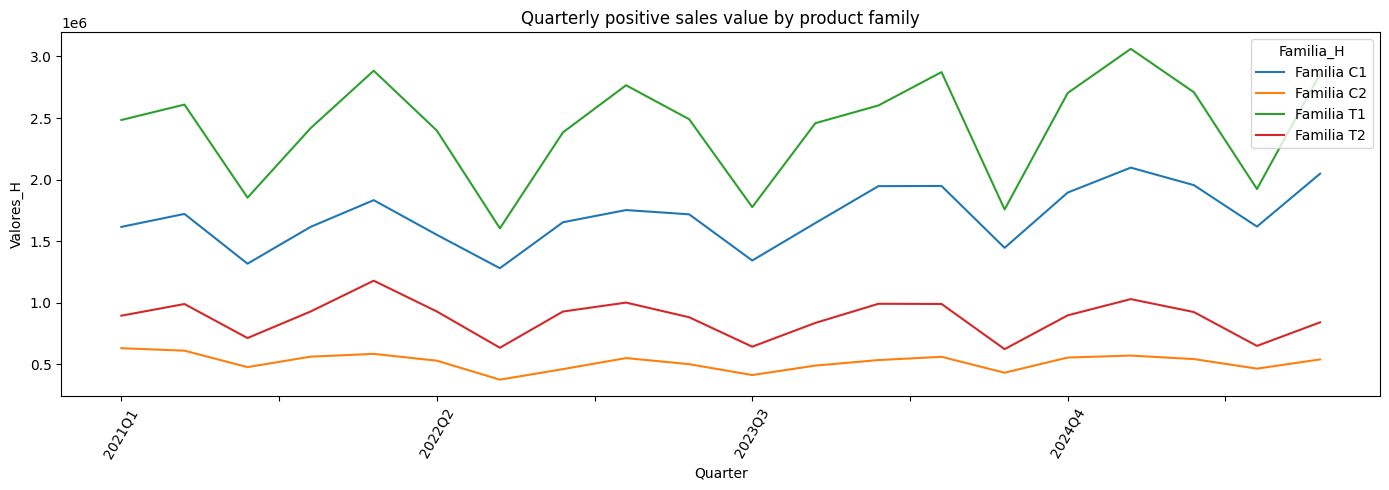

In [11]:
quarterly_family = ventas_pos.groupby(["Trimestre", "Familia_H"]).agg(
    value=("Valores_H", "sum"),
    clients=("Id. Cliente", "nunique"),
).reset_index()
display(quarterly_family.tail(16))

if HAS_MPL:
    q_pivot = quarterly_family.pivot(index="Trimestre", columns="Familia_H", values="value").fillna(0)
    ax = q_pivot.plot(figsize=(14, 5), title="Quarterly positive sales value by product family")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Valores_H")
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

## 6. Product Dimension

The challenge explicitly requires different treatment for `Commodities` and `Productos Técnicos`.

In [12]:
block_summary = ventas_pos.groupby("Bloque analítico").agg(
    rows=("Num.Fact", "size"),
    invoices=("Num.Fact", "nunique"),
    clients=("Id. Cliente", "nunique"),
    products=("Id. Producto", "nunique"),
    units=("Unidades", "sum"),
    value=("Valores_H", "sum"),
).reset_index()
block_summary["value_share"] = block_summary["value"] / block_summary["value"].sum()
display(block_summary)

,Bloque analítico,rows,invoices,clients,products,units,value,value_share
0,Commodities,96405,59736,6359,8,617694,"44,421,401.84",0.40
1,Productos Técnicos,60516,40928,4221,17,177313,"66,145,548.64",0.60


In [13]:
family_summary = ventas_pos.groupby(["Bloque analítico", "Familia_H", "Categoria_H"]).agg(
    rows=("Num.Fact", "size"),
    clients=("Id. Cliente", "nunique"),
    products=("Id. Producto", "nunique"),
    units=("Unidades", "sum"),
    value=("Valores_H", "sum"),
    avg_order_value=("Valores_H", "mean"),
).sort_values("value", ascending=False).reset_index()
family_summary["value_share"] = family_summary["value"] / family_summary["value"].sum()
display(family_summary)

,Bloque analítico,Familia_H,Categoria_H,rows,clients,products,units,value,avg_order_value,value_share
0,Productos Técnicos,Familia T1,Categoria T1,42381,4012,10,135748,"48,622,139.21","1,147.26",0.44
1,Commodities,Familia C1,Categoria C1,74806,5896,6,385110,"34,017,016.80",454.74,0.31
2,Productos Técnicos,Familia T2,Categoria T1,18135,2533,7,41565,"17,523,409.43",966.28,0.16
3,Commodities,Familia C2,Categoria C2,21599,2526,2,232584,"10,404,385.04",481.71,0.09


,Id. Producto,Bloque analítico,Familia_H,Categoria_H,rows,clients,units,value,cumulative_value_share
0,5099,Productos Técnicos,Familia T1,Categoria T1,22794,2980,87697,"23,068,053.08",0.21
1,4566,Commodities,Familia C1,Categoria C1,28657,4333,166392,"16,098,387.94",0.35
2,5115,Productos Técnicos,Familia T2,Categoria T1,11497,1924,27867,"11,808,430.17",0.46
3,5103,Productos Técnicos,Familia T1,Categoria T1,6238,1286,14908,"11,655,550.29",0.57
4,4565,Commodities,Familia C1,Categoria C1,13836,2419,77076,"7,464,076.70",0.63
5,3408,Commodities,Familia C1,Categoria C1,20753,3615,114978,"7,114,578.81",0.70
6,5108,Productos Técnicos,Familia T1,Categoria T1,5663,1226,14276,"6,974,415.18",0.76
7,4912,Commodities,Familia C2,Categoria C2,13308,1935,180323,"6,389,945.28",0.82
8,4911,Commodities,Familia C2,Categoria C2,8291,1986,52261,"4,014,439.76",0.86
9,5107,Productos Técnicos,Familia T1,Categoria T1,3556,938,7314,"3,671,535.81",0.89


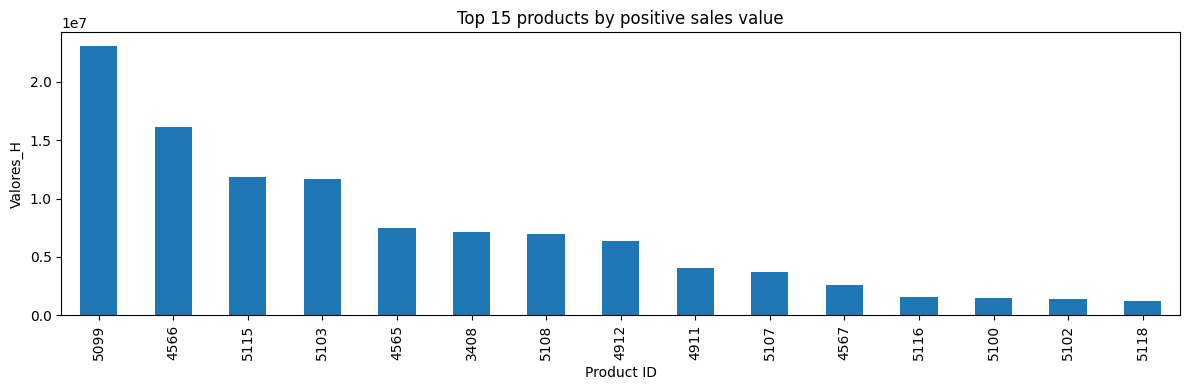

In [14]:
product_summary = ventas_pos.groupby(["Id. Producto", "Bloque analítico", "Familia_H", "Categoria_H"]).agg(
    rows=("Num.Fact", "size"),
    clients=("Id. Cliente", "nunique"),
    units=("Unidades", "sum"),
    value=("Valores_H", "sum"),
).sort_values("value", ascending=False).reset_index()
product_summary["cumulative_value_share"] = product_summary["value"].cumsum() / product_summary["value"].sum()
display(product_summary.head(15))

if HAS_MPL:
    ax = product_summary.head(15).plot(kind="bar", x="Id. Producto", y="value", figsize=(12, 4), legend=False, title="Top 15 products by positive sales value")
    ax.set_xlabel("Product ID")
    ax.set_ylabel("Valores_H")
    plt.tight_layout()
    plt.show()

## 7. Customer Dimension

RFM-style features are useful both for sales prioritization and for later supervised/heuristic alert design.

In [15]:
analysis_date = ventas_pos["Fecha"].max() + pd.Timedelta(days=1)
customer_rfm = ventas_pos.groupby("Id. Cliente").agg(
    first_purchase=("Fecha", "min"),
    last_purchase=("Fecha", "max"),
    active_months=("Mes", "nunique"),
    invoices=("Num.Fact", "nunique"),
    products=("Id. Producto", "nunique"),
    families=("Familia_H", "nunique"),
    units=("Unidades", "sum"),
    value=("Valores_H", "sum"),
).reset_index()
customer_rfm["recency_days"] = (analysis_date - customer_rfm["last_purchase"]).dt.days
customer_rfm["tenure_days"] = (customer_rfm["last_purchase"] - customer_rfm["first_purchase"]).dt.days.clip(lower=1)
customer_rfm["orders_per_active_month"] = customer_rfm["invoices"] / customer_rfm["active_months"].replace(0, np.nan)
customer_rfm["value_per_invoice"] = customer_rfm["value"] / customer_rfm["invoices"].replace(0, np.nan)
customer_rfm = customer_rfm.merge(clientes_master[["Id. Cliente", "Provincia"]], on="Id. Cliente", how="left")

display(customer_rfm.sort_values("value", ascending=False).head(15))

,Id. Cliente,first_purchase,last_purchase,active_months,invoices,products,families,units,value,recency_days,tenure_days,orders_per_active_month,value_per_invoice,Provincia
3263,40439,2021-01-19,2025-12-16,50,167,6,4,1717,"775,471.07",14,1792,3.34,"4,643.54",Zaragoza
2302,29716,2021-01-20,2025-11-19,57,150,11,3,1807,"530,608.97",41,1764,2.63,"3,537.39",Pontevedra
2884,36492,2021-01-07,2025-12-23,59,497,8,3,1473,"477,817.07",7,1811,8.42,961.40,Navarra
2416,30857,2021-01-13,2025-12-23,56,132,12,4,976,"377,111.33",7,1805,2.36,"2,856.90",Vizcaya
5476,1000078921,2021-01-15,2025-11-04,33,38,7,3,1008,"322,565.04",56,1754,1.15,"8,488.55",Vizcaya
5699,1000079859,2021-01-08,2025-12-05,44,63,4,2,1290,"296,498.14",25,1792,1.43,"4,706.32",Asturias
2907,36639,2021-01-08,2025-12-10,57,165,10,3,1324,"288,946.41",20,1797,2.89,"1,751.19",Barcelona
4249,1000060942,2021-01-11,2025-12-19,52,145,7,2,902,"282,550.23",11,1803,2.79,"1,948.62",Cádiz
3004,37468,2021-01-20,2025-11-27,26,31,4,3,1098,"282,500.65",33,1772,1.19,"9,112.92",Cantabria
5118,1000077135,2021-02-05,2025-06-23,48,97,9,4,726,"276,708.83",190,1599,2.02,"2,852.67",Madrid


In [16]:
customer_distribution = customer_rfm[["value", "invoices", "active_months", "products", "families", "recency_days", "value_per_invoice"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
display(customer_distribution)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
value,"8,071.00","13,699.29","26,764.14",61.58,786.38,"1,960.21","5,661.61","14,273.67","32,289.50","52,487.52","121,685.89","775,471.07"
invoices,"8,071.00",12.04,17.29,1.00,1.00,3.00,7.00,15.00,28.00,41.00,76.00,497.00
active_months,"8,071.00",9.98,10.39,1.00,1.00,2.00,6.00,14.00,24.00,32.00,47.00,59.00
products,"8,071.00",3.73,2.40,1.00,1.00,2.00,3.00,5.00,7.00,9.00,11.00,19.00
families,"8,071.00",1.85,0.94,1.00,1.00,1.00,2.00,2.00,3.00,4.00,4.00,4.00
recency_days,"8,071.00",379.31,481.48,1.00,27.00,49.00,154.00,523.00,"1,253.00","1,512.00","1,749.60","1,821.00"
value_per_invoice,"8,071.00","1,047.59",891.82,61.58,393.19,573.36,845.92,"1,240.79","1,795.74","2,410.68","4,215.83","18,311.10"


,value_share_target,customers_needed,share_of_customers
0,0.50,770,0.10
1,0.80,2471,0.31
2,0.90,3735,0.46


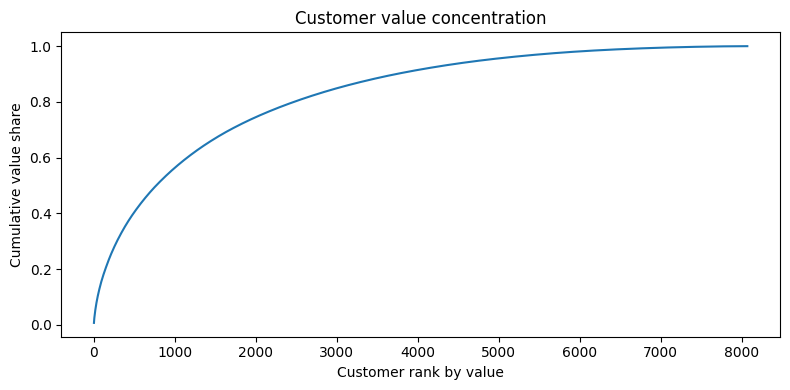

In [17]:
customer_concentration = customer_rfm.sort_values("value", ascending=False).reset_index(drop=True)
customer_concentration["customer_rank"] = np.arange(1, len(customer_concentration) + 1)
customer_concentration["cum_value_share"] = customer_concentration["value"].cumsum() / customer_concentration["value"].sum()
thresholds = [0.5, 0.8, 0.9]
rows = []
for threshold in thresholds:
    reached = customer_concentration[customer_concentration["cum_value_share"] >= threshold].head(1)
    rows.append({
        "value_share_target": threshold,
        "customers_needed": int(reached["customer_rank"].iloc[0]),
        "share_of_customers": float(reached["customer_rank"].iloc[0] / len(customer_concentration)),
    })
display(pd.DataFrame(rows))

if HAS_MPL:
    ax = customer_concentration.plot(x="customer_rank", y="cum_value_share", figsize=(8, 4), legend=False, title="Customer value concentration")
    ax.set_xlabel("Customer rank by value")
    ax.set_ylabel("Cumulative value share")
    plt.tight_layout()
    plt.show()

## 8. Geography Dimension

,Provincia,clients,invoices,units,value,value_per_client,value_share
0,Madrid,1445,19302,140326,"20,362,406.05","14,091.63",0.18
1,Barcelona,875,10272,82940,"12,087,680.42","13,814.49",0.11
2,Valencia,460,4441,34413,"5,473,042.83","11,897.92",0.05
3,Sevilla,367,4116,40820,"4,595,887.03","12,522.85",0.04
4,Vizcaya,209,2077,25984,"4,449,583.82","21,289.87",0.04
5,Zaragoza,193,2745,19453,"4,117,568.92","21,334.55",0.04
6,Sta.Cruz Tenerife,269,3947,32049,"3,440,876.02","12,791.36",0.03
7,Asturias,237,2197,18922,"3,231,013.87","13,632.97",0.03
8,Pontevedra,166,2270,21260,"2,826,738.31","17,028.54",0.03
9,A Coruña,237,2982,23991,"2,744,484.72","11,580.10",0.02


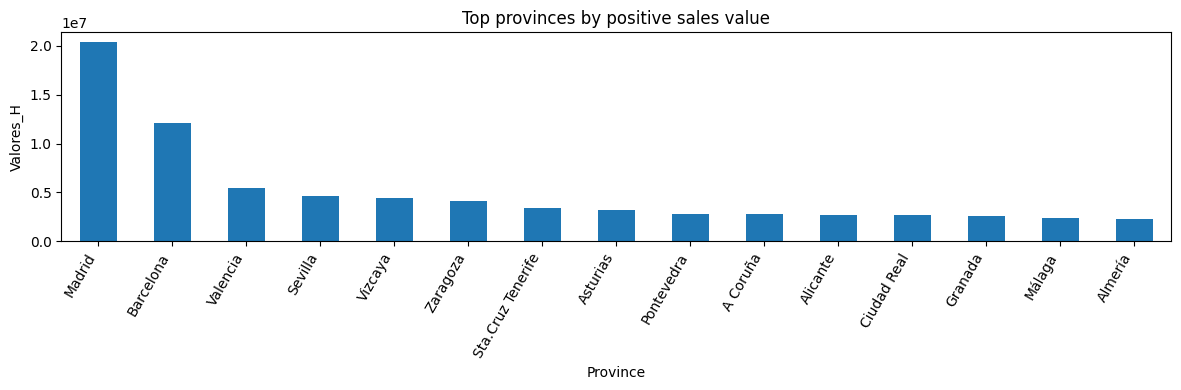

In [18]:
province_summary = ventas_pos.groupby("Provincia").agg(
    clients=("Id. Cliente", "nunique"),
    invoices=("Num.Fact", "nunique"),
    units=("Unidades", "sum"),
    value=("Valores_H", "sum"),
).sort_values("value", ascending=False).reset_index()
province_summary["value_per_client"] = province_summary["value"] / province_summary["clients"].replace(0, np.nan)
province_summary["value_share"] = province_summary["value"] / province_summary["value"].sum()
display(province_summary.head(20))

if HAS_MPL:
    ax = province_summary.head(15).plot(kind="bar", x="Provincia", y="value", figsize=(12, 4), legend=False, title="Top provinces by positive sales value")
    ax.set_xlabel("Province")
    ax.set_ylabel("Valores_H")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

In [19]:
province_block = ventas_pos.groupby(["Provincia", "Bloque analítico"]).agg(value=("Valores_H", "sum"), clients=("Id. Cliente", "nunique")).reset_index()
province_block_pivot = province_block.pivot(index="Provincia", columns="Bloque analítico", values="value").fillna(0)
province_block_pivot["total"] = province_block_pivot.sum(axis=1)
province_block_pivot = province_block_pivot.sort_values("total", ascending=False)
display(province_block_pivot.head(20))

Bloque analítico,Commodities,Productos Técnicos,total
Provincia,,,
Madrid,"7,595,932.74","12,766,473.31","20,362,406.05"
Barcelona,"4,961,123.60","7,126,556.81","12,087,680.42"
Valencia,"1,719,349.39","3,753,693.44","5,473,042.83"
Sevilla,"2,377,411.75","2,218,475.28","4,595,887.03"
Vizcaya,"1,500,050.60","2,949,533.22","4,449,583.82"
Zaragoza,"979,020.16","3,138,548.75","4,117,568.92"
Sta.Cruz Tenerife,"2,013,217.19","1,427,658.84","3,440,876.02"
Asturias,"998,048.53","2,232,965.34","3,231,013.87"
Pontevedra,"1,102,248.68","1,724,489.63","2,826,738.31"


## 9. Potential vs. Observed Sales

`Potencial` is at customer-category level. The join below compares potential to observed positive value using product `Categoria_H`. This is a first-pass opportunity map, not a final commercial truth.

In [20]:
potencial["Potencial_H"] = pd.to_numeric(potencial["Potencial_H"], errors="coerce")
actual_by_client_category = ventas_pos.groupby(["Id. Cliente", "Categoria_H"]).agg(
    observed_value=("Valores_H", "sum"),
    observed_units=("Unidades", "sum"),
    last_purchase=("Fecha", "max"),
    invoices=("Num.Fact", "nunique"),
).reset_index()

potential_vs_actual = potencial.merge(
    actual_by_client_category,
    left_on=["Id.Cliente", "Categoria Productos"],
    right_on=["Id. Cliente", "Categoria_H"],
    how="left",
)
potential_vs_actual["observed_value"] = potential_vs_actual["observed_value"].fillna(0)
potential_vs_actual["observed_units"] = potential_vs_actual["observed_units"].fillna(0)
potential_vs_actual["invoices"] = potential_vs_actual["invoices"].fillna(0)
potential_vs_actual["capture_ratio"] = potential_vs_actual["observed_value"] / potential_vs_actual["Potencial_H"].replace(0, np.nan)
potential_vs_actual["uncaptured_potential"] = (potential_vs_actual["Potencial_H"] - potential_vs_actual["observed_value"]).clip(lower=0)

potential_summary = potential_vs_actual.groupby(["Familia", "Categoria Productos"]).agg(
    customers=("Id.Cliente", "nunique"),
    potential=("Potencial_H", "sum"),
    observed_value=("observed_value", "sum"),
    uncaptured_potential=("uncaptured_potential", "sum"),
    median_capture_ratio=("capture_ratio", "median"),
).reset_index()
potential_summary["aggregate_capture_ratio"] = potential_summary["observed_value"] / potential_summary["potential"].replace(0, np.nan)
display(potential_summary.sort_values("uncaptured_potential", ascending=False))

,Familia,Categoria Productos,customers,potential,observed_value,uncaptured_potential,median_capture_ratio,aggregate_capture_ratio
1,Biomateriales,Categoria C2,10976,"63,309,041.10","10,404,385.04","56,030,879.25",0.00,0.16
0,Anestesia,Categoria C1,11031,"28,171,081.48","34,017,016.80","15,707,276.42",0.20,1.21
3,Bioseguridad,Categoria C2,11031,"13,767,502.70","10,404,385.04","11,147,406.32",0.00,0.76
2,Biomateriales,Categoria T1,55,0.00,0.00,0.00,NaN,NaN


In [21]:
# Candidate commodity opportunities: high potential, low observed capture, recent enough to be actionable.
commodity_opportunities = potential_vs_actual[potential_vs_actual["Categoria Productos"].isin(["Categoria C1", "Categoria C2"])].copy()
commodity_opportunities = commodity_opportunities.merge(
    clientes_master[["Id. Cliente", "Provincia"]],
    left_on="Id.Cliente",
    right_on="Id. Cliente",
    how="left",
    suffixes=("", "_cliente"),
)
commodity_opportunities["last_purchase"] = pd.to_datetime(commodity_opportunities["last_purchase"], errors="coerce")
commodity_opportunities["days_since_last_purchase"] = (analysis_date - commodity_opportunities["last_purchase"]).dt.days
cols = ["Id.Cliente", "Provincia", "Familia", "Categoria Productos", "Potencial_H", "observed_value", "capture_ratio", "uncaptured_potential", "invoices", "days_since_last_purchase"]
display(commodity_opportunities.sort_values(["uncaptured_potential", "Potencial_H"], ascending=False)[cols].head(20))

,Id.Cliente,Provincia,Familia,Categoria Productos,Potencial_H,observed_value,capture_ratio,uncaptured_potential,invoices,days_since_last_purchase
15272,41482,Ciudad Real,Biomateriales,Categoria C2,"208,065.82","3,197.43",0.02,"204,868.39",23.00,119.00
12715,17168,Málaga,Biomateriales,Categoria C2,"110,967.60",0.00,0.00,"110,967.60",0.00,NaN
13287,24229,Málaga,Biomateriales,Categoria C2,"110,967.60",0.00,0.00,"110,967.60",0.00,NaN
14222,32845,Madrid,Biomateriales,Categoria C2,"110,967.60",0.00,0.00,"110,967.60",0.00,NaN
14635,36492,Navarra,Biomateriales,Categoria C2,"106,345.52","2,310.38",0.02,"104,035.14",11.00,"1,406.00"
14035,30870,Guadalajara,Biomateriales,Categoria C2,"103,569.76",163.72,0.00,"103,406.04",1.00,"1,267.00"
18270,1000079859,Asturias,Biomateriales,Categoria C2,"92,473.00",0.00,0.00,"92,473.00",0.00,NaN
19177,1000081536,Cádiz,Biomateriales,Categoria C2,"92,473.00",0.00,0.00,"92,473.00",0.00,NaN
19095,1000081418,Sevilla,Biomateriales,Categoria C2,"83,225.70",0.00,0.00,"83,225.70",0.00,NaN
11875,8849,Valladolid,Biomateriales,Categoria C2,"92,473.00","14,545.42",0.16,"77,927.58",23.00,25.00


## 10. Campaign Windows

This creates a simple campaign flag for sales rows and compares sales inside and outside campaigns. A more rigorous version would add pre/post windows by campaign and product category.

In [22]:
campanias["Fecha inicio"] = pd.to_datetime(campanias["Fecha inicio"], errors="coerce")
campanias["Fecha fin"] = pd.to_datetime(campanias["Fecha fin"], errors="coerce")

def assign_campaign(date):
    matches = campanias[(campanias["Fecha inicio"] <= date) & (campanias["Fecha fin"] >= date)]
    if len(matches):
        return matches.iloc[0]["Campaña"]
    return np.nan

ventas_pos["Campaña"] = ventas_pos["Fecha"].map(assign_campaign)
ventas_pos["En_campaña"] = ventas_pos["Campaña"].notna()

campaign_summary = ventas_pos.groupby("En_campaña").agg(
    rows=("Num.Fact", "size"),
    clients=("Id. Cliente", "nunique"),
    invoices=("Num.Fact", "nunique"),
    units=("Unidades", "sum"),
    value=("Valores_H", "sum"),
    avg_invoice_line_value=("Valores_H", "mean"),
).reset_index()
display(campaign_summary)

campaign_detail = ventas_pos[ventas_pos["En_campaña"]].groupby(["Campaña", "Bloque analítico"]).agg(
    rows=("Num.Fact", "size"),
    clients=("Id. Cliente", "nunique"),
    value=("Valores_H", "sum"),
).reset_index().sort_values(["Campaña", "value"], ascending=[True, False])
display(campaign_detail)

,En_campaña,rows,clients,invoices,units,value,avg_invoice_line_value
0,False,150194,8026,93187,760630,"105,946,681.03",705.40
1,True,6727,2547,3977,34377,"4,620,269.44",686.82


,Campaña,Bloque analítico,rows,clients,value
1,2021_1,Productos Técnicos,192,126,"201,837.50"
0,2021_1,Commodities,328,207,"137,707.59"
3,2022_1,Productos Técnicos,879,499,"1,046,782.68"
2,2022_1,Commodities,1197,661,"542,691.76"
5,2022_2,Productos Técnicos,108,76,"97,972.40"
4,2022_2,Commodities,216,113,"89,775.99"
7,2023_1,Productos Técnicos,265,163,"282,190.89"
6,2023_1,Commodities,437,262,"204,939.10"
9,2023_2,Productos Técnicos,84,59,"85,116.23"
8,2023_2,Commodities,142,75,"71,470.11"


## 11. Repurchase and Churn Signal Feature Prototypes

These are not final models. They are transparent baseline features that can seed daily commercial alerts.

In [23]:
# Client-family purchase cadence.
cf_events = ventas_pos.sort_values(["Id. Cliente", "Familia_H", "Fecha"]).copy()
cf_events["prev_purchase_date"] = cf_events.groupby(["Id. Cliente", "Familia_H"])["Fecha"].shift(1)
cf_events["days_since_prev_purchase"] = (cf_events["Fecha"] - cf_events["prev_purchase_date"]).dt.days

cadence = cf_events.groupby(["Id. Cliente", "Bloque analítico", "Familia_H"]).agg(
    purchases=("Fecha", "count"),
    first_purchase=("Fecha", "min"),
    last_purchase=("Fecha", "max"),
    median_gap_days=("days_since_prev_purchase", "median"),
    p75_gap_days=("days_since_prev_purchase", lambda s: s.dropna().quantile(0.75) if s.dropna().size else np.nan),
    total_value=("Valores_H", "sum"),
).reset_index()
cadence["days_since_last_purchase"] = (analysis_date - cadence["last_purchase"]).dt.days
cadence["overdue_ratio_vs_median"] = cadence["days_since_last_purchase"] / cadence["median_gap_days"].replace(0, np.nan)
cadence["overdue_ratio_vs_p75"] = cadence["days_since_last_purchase"] / cadence["p75_gap_days"].replace(0, np.nan)

display(cadence.sort_values("total_value", ascending=False).head(20))

,Id. Cliente,Bloque analítico,Familia_H,purchases,first_purchase,last_purchase,median_gap_days,p75_gap_days,total_value,days_since_last_purchase,overdue_ratio_vs_median,overdue_ratio_vs_p75
6372,40439,Productos Técnicos,Familia T1,107,2021-07-20,2025-12-16,10.00,15.00,"666,221.18",14,1.40,0.93
4431,29716,Productos Técnicos,Familia T1,90,2021-01-20,2025-11-19,18.00,24.00,"479,933.93",41,2.28,1.71
5587,36492,Productos Técnicos,Familia T1,907,2021-01-07,2025-12-23,0.00,2.00,"457,372.12",7,NaN,3.50
4664,30857,Productos Técnicos,Familia T1,131,2021-01-13,2025-12-11,8.50,21.00,"317,877.15",19,2.24,0.90
8127,1000060942,Productos Técnicos,Familia T1,281,2021-01-11,2025-12-19,1.00,8.00,"278,146.76",11,11.00,1.38
5207,34365,Productos Técnicos,Familia T1,47,2021-01-07,2025-12-17,33.00,45.25,"275,773.23",13,0.39,0.29
10850,1000079859,Productos Técnicos,Familia T1,38,2021-01-08,2025-10-22,44.00,54.00,"266,127.25",69,1.57,1.28
964,6546,Productos Técnicos,Familia T1,35,2021-02-04,2025-11-14,52.00,75.25,"256,758.71",46,0.88,0.61
5735,37067,Productos Técnicos,Familia T1,51,2021-01-08,2025-12-23,26.00,43.75,"231,571.73",7,0.27,0.16
5634,36639,Productos Técnicos,Familia T1,126,2021-01-08,2025-11-24,9.00,23.00,"205,768.00",36,4.00,1.57


In [24]:
commodity_repurchase_candidates = cadence[
    (cadence["Bloque analítico"] == "Commodities")
    & (cadence["purchases"] >= 3)
    & (cadence["median_gap_days"].notna())
].copy()
commodity_repurchase_candidates["alert_score"] = (
    commodity_repurchase_candidates["overdue_ratio_vs_p75"].fillna(0).clip(lower=0)
    * np.log1p(commodity_repurchase_candidates["total_value"])
)
commodity_repurchase_candidates = commodity_repurchase_candidates.sort_values("alert_score", ascending=False)
display(commodity_repurchase_candidates[[
    "Id. Cliente", "Familia_H", "purchases", "last_purchase", "median_gap_days", "p75_gap_days", "days_since_last_purchase", "overdue_ratio_vs_p75", "total_value", "alert_score"
]].head(25))

,Id. Cliente,Familia_H,purchases,last_purchase,median_gap_days,p75_gap_days,days_since_last_purchase,overdue_ratio_vs_p75,total_value,alert_score
12653,1000082106,Familia C1,3,2021-05-07,0.50,0.75,1698,"2,264.00",701.92,"14,841.06"
7580,1000037428,Familia C1,3,2021-11-25,0.50,0.75,1496,"1,994.67","1,372.05","14,411.05"
7065,42504,Familia C1,3,2023-03-09,0.50,0.75,1027,"1,369.33","3,088.25","11,003.53"
6698,41683,Familia C1,8,2022-01-14,0.00,1.50,1446,964.00,"3,892.09","7,969.35"
39,163,Familia C1,6,2021-07-22,0.00,2.00,1622,811.00,"1,041.60","5,636.02"
10128,1000078305,Familia C2,3,2022-12-23,1.00,1.50,1103,735.33,"1,890.19","5,548.06"
8851,1000070578,Familia C1,5,2022-02-24,0.00,2.00,1405,702.50,"1,819.82","5,273.70"
12241,1000081733,Familia C1,10,2024-09-17,0.00,1.00,469,469.00,"4,848.32","3,980.21"
7402,42981,Familia C1,3,2024-12-11,0.50,0.75,384,512.00,"1,335.88","3,685.42"
9731,1000077009,Familia C1,4,2021-12-09,0.00,3.00,1482,494.00,"1,691.74","3,672.45"


In [25]:
technical_churn_candidates = cadence[
    (cadence["Bloque analítico"] == "Productos Técnicos")
    & (cadence["purchases"] >= 2)
].copy()
technical_churn_candidates["alert_score"] = (
    technical_churn_candidates["overdue_ratio_vs_p75"].fillna(0).clip(lower=0)
    * np.log1p(technical_churn_candidates["total_value"])
)
technical_churn_candidates = technical_churn_candidates.sort_values("alert_score", ascending=False)
display(technical_churn_candidates[[
    "Id. Cliente", "Familia_H", "purchases", "last_purchase", "median_gap_days", "p75_gap_days", "days_since_last_purchase", "overdue_ratio_vs_p75", "total_value", "alert_score"
]].head(25))

,Id. Cliente,Familia_H,purchases,last_purchase,median_gap_days,p75_gap_days,days_since_last_purchase,overdue_ratio_vs_p75,total_value,alert_score
11123,1000080298,Familia T2,2,2021-06-18,1.00,1.00,1656,"1,656.00","2,502.77","12,959.11"
3732,26085,Familia T2,2,2021-11-16,1.00,1.00,1505,"1,505.00",967.18,"10,347.51"
4143,28127,Familia T2,2,2022-04-20,1.00,1.00,1350,"1,350.00","1,558.35","9,925.23"
11612,1000080944,Familia T2,2,2022-01-26,1.00,1.00,1434,"1,434.00",916.50,"9,782.25"
8377,1000065578,Familia T2,2,2022-06-14,1.00,1.00,1295,"1,295.00",914.24,"8,830.85"
10084,1000078226,Familia T1,11,2022-03-23,0.00,1.50,1378,918.67,"7,315.63","8,174.21"
8817,1000070086,Familia T1,4,2021-04-22,3.00,3.50,1713,489.43,"4,034.96","4,063.73"
13822,1000100419,Familia T1,4,2023-09-22,0.00,2.00,830,415.00,"2,945.92","3,315.23"
11876,1000081303,Familia T1,2,2021-04-06,5.00,5.00,1729,345.80,"2,394.63","2,690.81"
8380,1000065611,Familia T2,2,2021-02-01,5.00,5.00,1793,358.60,"1,212.51","2,546.52"


## 12. Suggested Next Analysis Steps

- Validate negative-unit rows as returns, cancellations, or accounting adjustments before using net sales as demand.
- Build customer-family daily snapshots with features available at that date only.
- For commodities, test expected repurchase windows using client-family cadence and potential capture ratio.
- For technical products, combine recency, historical cadence, value decline, and product-family usage profile to avoid flagging normal pauses as churn.
- Add feedback fields for generated alert, commercial action, outcome, and false-positive reason so the system can learn from usage.